### Top 500 Movies Ranked by IMDb, Rotten & Letterboxd
- Data Collection from Flickmetrix and enriched 
- Data aggregated rating from multiple platforms, including:
    - IMDb
    - Metacritic
    - Rotten Tomatoes
    - Letterboxd
    - Google Users



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Top 500 Movies.csv")
data.head()

,Rank,Title,Year,Genre,Director,Cast,Language,Plot,Awards,Production,...,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Streaming_On,RT_URL,imdbID,Custom_Score
0,1,The Godfather,1972,"Drama, Crime",Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan, Robert D...",en,"Spanning the years 1945 to 1955, a chronicle o...",Won 3 Oscars. Another 30 wins & 19 nominations.,Paramount Pictures,...,104,95.0,1087289.0,90,1789555.0,90.0,"paramount, itunes, amzvid",https://www.rottentomatoes.com/m/godfather,tt0068646,93.83
1,2,Seven Samurai,1954,"Action, Drama",Akira Kurosawa,"Toshirō Mifune, Takashi Shimura, Yoshio Inaba,...",ja,A samurai answers a village's request for prot...,Nominated for 2 Oscars. Another 6 wins & 5 nom...,Columbia Pictures,...,68,94.0,167123.0,92,318537.0,93.0,"hbo, itunes, amzvid, hbm",https://www.rottentomatoes.com/m/seven_samurai...,tt0047478,93.33
2,3,12 Angry Men,1957,Drama,Sidney Lumet,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",en,The defense and the prosecution have rested an...,Nominated for 3 Oscars. Another 16 wins & 8 no...,Criterion Collection,...,58,94.0,376697.0,92,917590.0,91.0,"itunes, amzvid",https://www.rottentomatoes.com/m/1000013_12_an...,tt0050083,92.83
3,4,Schindler's List,1993,"Drama, History, War",Steven Spielberg,"Liam Neeson, Ben Kingsley, Ralph Fiennes, Caro...",en,The true story of how businessman Oskar Schind...,Won 7 Oscars. Another 74 wins & 26 nominations.,Universal Pictures,...,82,94.0,601555.0,90,978054.0,93.0,"itunes, amzvid",https://www.rottentomatoes.com/m/schindlers_list,tt0108052,92.50
4,5,The Godfather: Part II,1974,"Drama, Crime",Francis Ford Coppola,"Al Pacino, Robert Duvall, Diane Keaton, Robert...",en,In the continuing saga of the Corleone crime f...,Won 6 Oscars. Another 13 wins & 16 nominations.,Paramount Pictures,...,80,94.0,586600.0,92,934120.0,89.0,"paramount, itunes, amzvid",https://www.rottentomatoes.com/m/godfather_par...,tt0071562,91.67


In [3]:
print(data.shape)
data.describe()

(449, 26)


,Rank,Year,Flickmetrix_Score,IMDb_10,IMDb_100,IMDb_Votes,Metacritic,Critic_Rating_RT,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Custom_Score
count,449.000000,449.000000,449.000000,449.000000,449.000000,4.490000e+02,436.000000,449.000000,449.000000,401.000000,4.420000e+02,449.000000,4.480000e+02,446.000000,449.000000
mean,225.000000,1994.151448,83.884187,7.969488,79.694878,4.315229e+05,86.754587,85.581292,122.926503,85.748130,8.115906e+05,82.151448,7.029797e+05,85.807175,84.229866
std,129.759393,25.683153,2.685102,0.359911,3.599106,4.723575e+05,6.924011,4.844751,67.931731,5.018357,3.179307e+06,3.954457,7.575711e+05,5.459435,2.798203
min,1.000000,1920.000000,80.000000,7.100000,71.000000,1.194000e+04,65.000000,72.000000,50.000000,57.000000,1.759300e+04,68.000000,3.153500e+04,46.000000,77.000000
25%,113.000000,1976.000000,82.000000,7.700000,77.000000,1.019410e+05,82.000000,82.000000,70.000000,83.000000,7.716325e+04,80.000000,1.430270e+05,83.000000,82.170000
50%,225.000000,2003.000000,83.000000,8.000000,80.000000,2.312560e+05,87.000000,85.000000,100.000000,87.000000,1.982740e+05,82.000000,3.962565e+05,86.000000,83.670000
75%,337.000000,2015.000000,85.000000,8.200000,82.000000,6.460640e+05,92.000000,89.000000,156.000000,89.000000,5.818142e+05,84.000000,1.002294e+06,90.000000,86.000000
max,449.000000,2025.000000,93.000000,9.200000,92.000000,2.666368e+06,100.000000,98.000000,342.000000,95.000000,2.454920e+07,92.000000,3.771374e+06,98.000000,93.830000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               449 non-null    int64  
 1   Title              449 non-null    object 
 2   Year               449 non-null    int64  
 3   Genre              449 non-null    object 
 4   Director           449 non-null    object 
 5   Cast               448 non-null    object 
 6   Language           449 non-null    object 
 7   Plot               449 non-null    object 
 8   Awards             324 non-null    object 
 9   Production         329 non-null    object 
 10  Flickmetrix_Score  449 non-null    float64
 11  IMDb_10            449 non-null    float64
 12  IMDb_100           449 non-null    float64
 13  IMDb_Votes         449 non-null    int64  
 14  Metacritic         436 non-null    float64
 15  Critic_Rating_RT   449 non-null    float64
 16  Critic_Reviews     449 non

In [5]:
data_formate = data.copy()
data_formate.head()

,Rank,Title,Year,Genre,Director,Cast,Language,Plot,Awards,Production,...,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Streaming_On,RT_URL,imdbID,Custom_Score
0,1,The Godfather,1972,"Drama, Crime",Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan, Robert D...",en,"Spanning the years 1945 to 1955, a chronicle o...",Won 3 Oscars. Another 30 wins & 19 nominations.,Paramount Pictures,...,104,95.0,1087289.0,90,1789555.0,90.0,"paramount, itunes, amzvid",https://www.rottentomatoes.com/m/godfather,tt0068646,93.83
1,2,Seven Samurai,1954,"Action, Drama",Akira Kurosawa,"Toshirō Mifune, Takashi Shimura, Yoshio Inaba,...",ja,A samurai answers a village's request for prot...,Nominated for 2 Oscars. Another 6 wins & 5 nom...,Columbia Pictures,...,68,94.0,167123.0,92,318537.0,93.0,"hbo, itunes, amzvid, hbm",https://www.rottentomatoes.com/m/seven_samurai...,tt0047478,93.33
2,3,12 Angry Men,1957,Drama,Sidney Lumet,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",en,The defense and the prosecution have rested an...,Nominated for 3 Oscars. Another 16 wins & 8 no...,Criterion Collection,...,58,94.0,376697.0,92,917590.0,91.0,"itunes, amzvid",https://www.rottentomatoes.com/m/1000013_12_an...,tt0050083,92.83
3,4,Schindler's List,1993,"Drama, History, War",Steven Spielberg,"Liam Neeson, Ben Kingsley, Ralph Fiennes, Caro...",en,The true story of how businessman Oskar Schind...,Won 7 Oscars. Another 74 wins & 26 nominations.,Universal Pictures,...,82,94.0,601555.0,90,978054.0,93.0,"itunes, amzvid",https://www.rottentomatoes.com/m/schindlers_list,tt0108052,92.50
4,5,The Godfather: Part II,1974,"Drama, Crime",Francis Ford Coppola,"Al Pacino, Robert Duvall, Diane Keaton, Robert...",en,In the continuing saga of the Corleone crime f...,Won 6 Oscars. Another 13 wins & 16 nominations.,Paramount Pictures,...,80,94.0,586600.0,92,934120.0,89.0,"paramount, itunes, amzvid",https://www.rottentomatoes.com/m/godfather_par...,tt0071562,91.67


In [6]:
data_formate.drop(columns="Rank", axis=1, inplace=True)

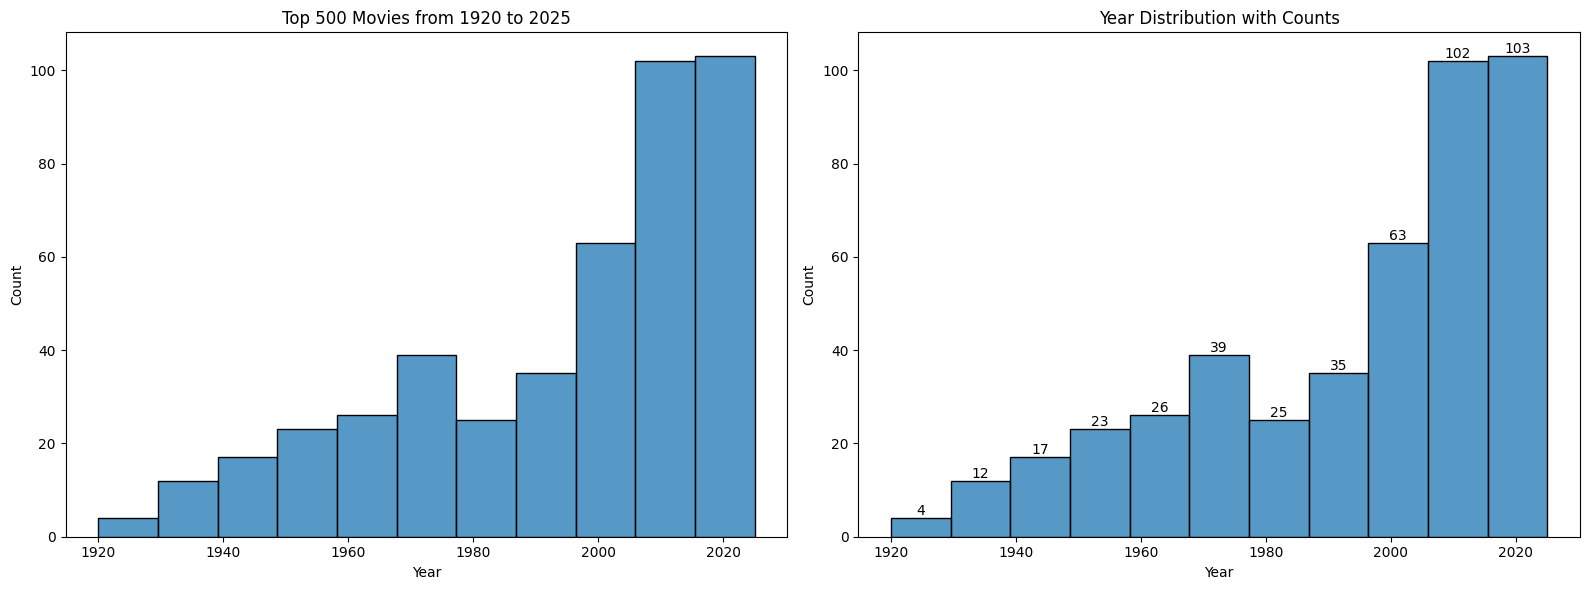

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First Graph
sns.histplot(x="Year", data=data_formate, ax=axes[0])
axes[0].set_title(
    f"Top 500 Movies from {data_formate['Year'].min()} to {data_formate['Year'].max()}"
)

# Second Graph
ax = sns.histplot(x="Year", data=data_formate, ax=axes[1])

for container in ax.containers:
    ax.bar_label(container)

axes[1].set_title("Year Distribution with Counts")

plt.tight_layout()
plt.show()

In [8]:
data_formate["Title"].value_counts()

Title
All Quiet on the Western Front                                          2
Judas and the Black Messiah                                             1
Society of the Snow                                                     1
Fire of Love                                                            1
Decision to Leave                                                       1
                                                                       ..
Goodfellas                                                              1
The Good, the Bad and the Ugly                                          1
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb    1
Casablanca                                                              1
The Battle of Algiers                                                   1
Name: count, Length: 448, dtype: int64

In [9]:
data_formate["Title"].value_counts()[lambda x: x > 1]

Title
All Quiet on the Western Front    2
Name: count, dtype: int64

In [10]:
data_formate.drop_duplicates(inplace=True)
data_formate.shape

(449, 25)

In [23]:
duplicate_rows = (
    data_formate[
        data_formate["Title"].duplicated(keep=False)
    ]
    .sort_values("Title")
)

dup_data = pd.DataFrame(duplicate_rows)
dup_data

,Title,Year,Genre,Director,Cast,Language,Plot,Production,Flickmetrix_Score,IMDb_10,...,IMDb_Votes,Metacritic,Critic_Rating_RT,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Custom_Score
202,All Quiet on the Western Front,1930,"Drama, War",Lewis Milestone,"Louis Wolheim, Lew Ayres, John Wray, Arnold Lucy",en,When a group of idealistic young men join the ...,Universal Pictures,84.0,8.1,...,69684,91.0,92.0,56,86.0,29586.0,84,52395.0,70.0,84.0
382,All Quiet on the Western Front,2022,"War, History, Drama",Edward Berger,"Felix Kammerer, Albrecht Schuch, Aaron Hilmer,...",de,"Paul Baumer and his friends Albert and Muller,...",NaN,82.0,7.8,...,272269,76.0,81.0,114,NaN,266337.0,80,791518.0,92.0,81.4


In [ ]:
data_formate.drop(columns=["Streaming_On","Awards","RT_URL","imdbID"],inplace=True)
data_formate.isnull().sum()

Title                  0
Year                   0
Genre                  0
Director               0
Cast                   1
Language               0
Plot                   0
Production           120
Flickmetrix_Score      0
IMDb_10                0
IMDb_100               0
IMDb_Votes             0
Metacritic            13
Critic_Rating_RT       0
Critic_Reviews         0
Audience_Rating       48
Audience_Reviews       7
Letterboxd             0
Letterboxd_Votes       0
Google_Score           3
Custom_Score           0
dtype: int64

In [13]:
na_data = data_formate[["Title","Year","Production","Letterboxd_Votes","Google_Score"]].copy()
na_data.head()

,Title,Year,Production,Letterboxd_Votes,Google_Score
0,The Godfather,1972,Paramount Pictures,1789555.0,90.0
1,Seven Samurai,1954,Columbia Pictures,318537.0,93.0
2,12 Angry Men,1957,Criterion Collection,917590.0,91.0
3,Schindler's List,1993,Universal Pictures,978054.0,93.0
4,The Godfather: Part II,1974,Paramount Pictures,934120.0,89.0


In [14]:
na_data["Letterboxd_Votes"].mean(),na_data["Letterboxd_Votes"].median()

(np.float64(702979.6741071428), np.float64(396256.5))

<Axes: xlabel='Letterboxd_Votes', ylabel='Count'>

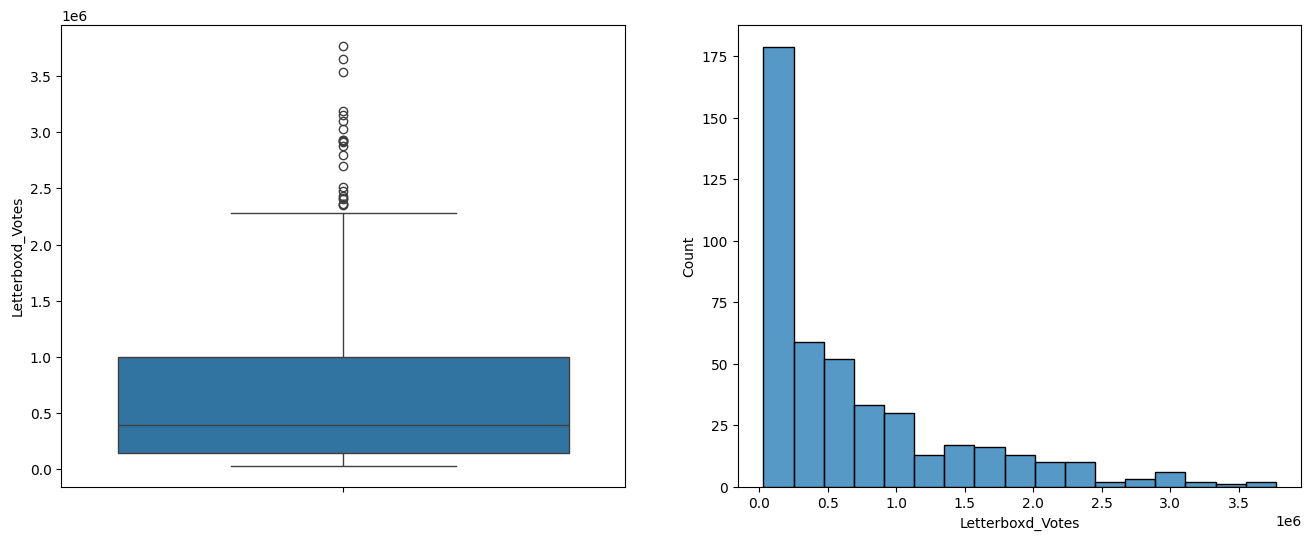

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(na_data["Letterboxd_Votes"],ax=axes[0])
sns.histplot(na_data["Letterboxd_Votes"],ax=axes[1])


In [ ]:
data_formate["Letterboxd_Votes"].fillna(data_formate["Letterboxd_Votes"].median(),inplace=True)


C:\Users\Abcom\AppData\Local\Temp\ipykernel_3860\2274212108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_formate["Letterboxd_Votes"].fillna(data_formate["Letterboxd_Votes"].median(),inplace=True)


In [17]:
data_formate.isnull().sum()

Title                  0
Year                   0
Genre                  0
Director               0
Cast                   1
Language               0
Plot                   0
Production           120
Flickmetrix_Score      0
IMDb_10                0
IMDb_100               0
IMDb_Votes             0
Metacritic            13
Critic_Rating_RT       0
Critic_Reviews         0
Audience_Rating       48
Audience_Reviews       7
Letterboxd             0
Letterboxd_Votes       0
Google_Score           3
imdbID                 0
Custom_Score           0
dtype: int64

In [18]:
year_reviews = (
    data_formate.groupby("Year")["Audience_Reviews"]
    .mean()
    .reset_index()
)

year_votes = (
    data_formate.groupby("Year")["Letterboxd_Votes"]
    .mean()
    .reset_index()
)

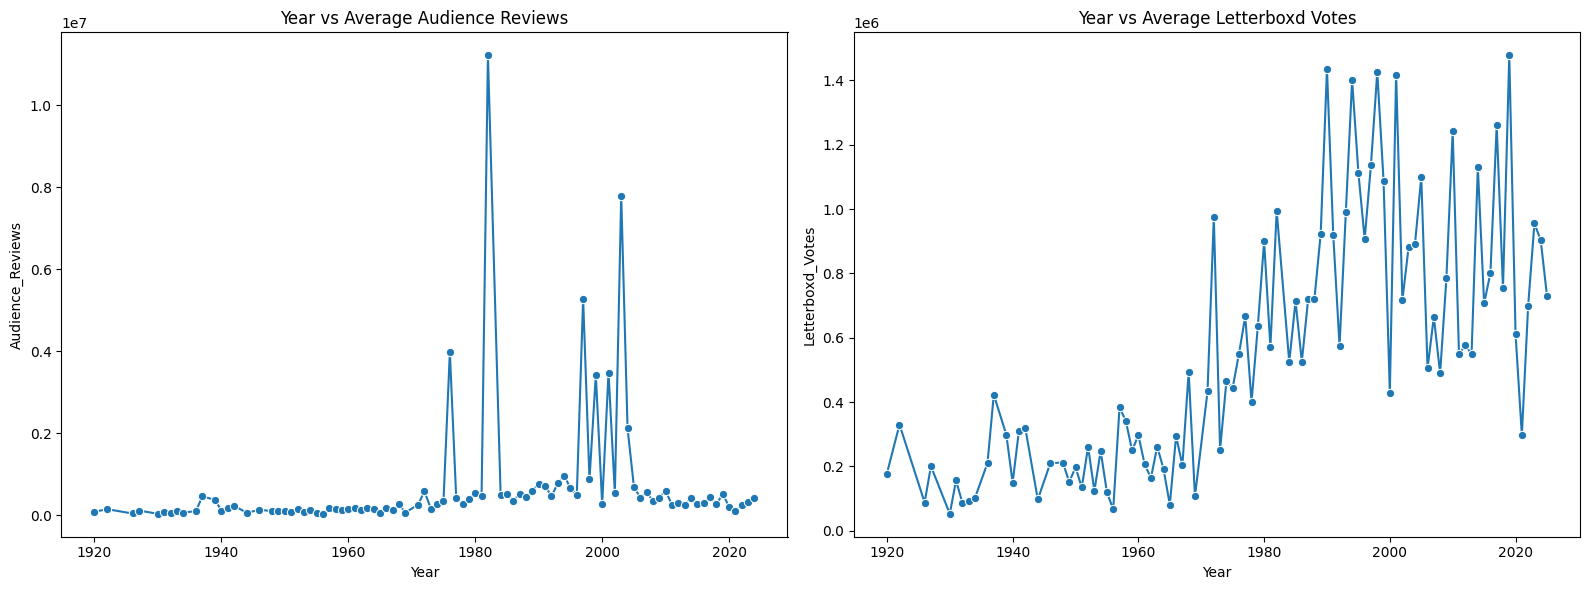

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Audience Reviews Trend
sns.lineplot(
    data=year_reviews,
    x="Year",
    y="Audience_Reviews",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Year vs Average Audience Reviews")

# Letterboxd Votes Trend
sns.lineplot(
    data=year_votes,
    x="Year",
    y="Letterboxd_Votes",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Year vs Average Letterboxd Votes")

plt.tight_layout()
plt.show()

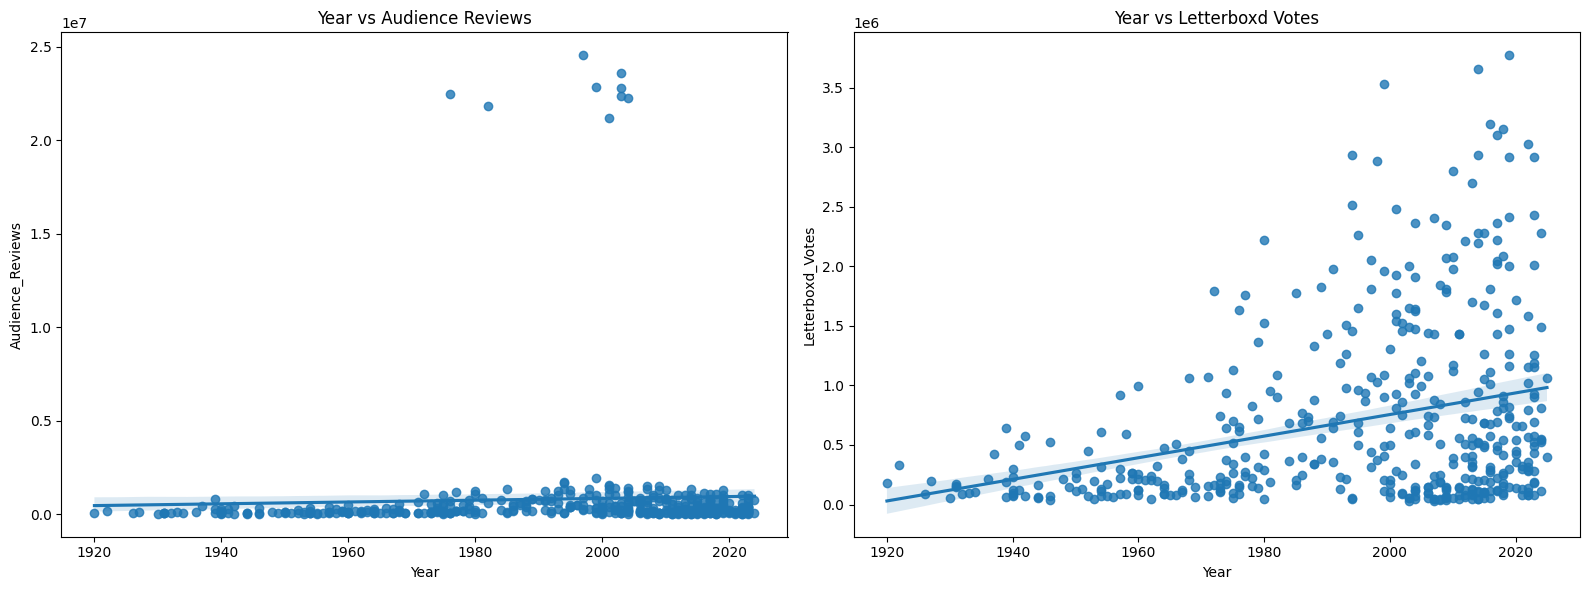

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=data_formate,
    x="Year",
    y="Audience_Reviews",
    ax=axes[0]
)

axes[0].set_title("Year vs Audience Reviews")

sns.regplot(
    data=data_formate,
    x="Year",
    y="Letterboxd_Votes",
    ax=axes[1]
)


axes[1].set_title("Year vs Letterboxd Votes")

plt.tight_layout()
plt.show()

### Now we are focusing on review which Platfor getting more review on which movie

In [34]:

data_formate["Language"].unique(), data_formate["Language_name"].unique()

(array(['en', 'ja', 'ko', 'it', 'fr', 'fa', 'de', 'es', 'sv', 'pt', 'cn',
        'ru', 'id', 'zh', 'lv', 'he', 'ro', 'ga', 'te', 'da', 'ar', 'tr',
        'no', 'pl', 'hi', 'gl', 'hu'], dtype=object),
 array(['English', 'Japanese', 'Korean', 'Italian', 'French', 'Persian',
        'German', 'Spanish', 'Swedish', 'Portuguese', 'Chinese', 'Russian',
        'Indonesian', 'Latvian', 'Hebrew', 'Romanian', 'Irish', 'Telugu',
        'Danish', 'Arabic', 'Turkish', 'Norwegian', 'Polish', 'Hindi',
        'Galician', 'Hungarian'], dtype=object))

In [33]:
lang_map = {
    'en': 'English',
    'ja': 'Japanese',
    'ko': 'Korean',
    'it': 'Italian',
    'fr': 'French',
    'fa': 'Persian',
    'de': 'German',
    'es': 'Spanish',
    'sv': 'Swedish',
    'pt': 'Portuguese',
    'cn': 'Chinese',
    'zh': 'Chinese',
    'ru': 'Russian',
    'id': 'Indonesian',
    'lv': 'Latvian',
    'he': 'Hebrew',
    'ro': 'Romanian',
    'ga': 'Irish',
    'te': 'Telugu',
    'da': 'Danish',
    'ar': 'Arabic',
    'tr': 'Turkish',
    'no': 'Norwegian',
    'pl': 'Polish',
    'hi': 'Hindi',
    'gl': 'Galician',
    'hu': 'Hungarian'
}

data_formate["Language_name"] = data_formate["Language"].map(lang_map)

In [38]:
print(data_formate.columns)
data_formate.head(3)

Index(['Title', 'Year', 'Genre', 'Director', 'Cast', 'Language', 'Plot',
       'Production', 'Flickmetrix_Score', 'IMDb_10', 'IMDb_100', 'IMDb_Votes',
       'Metacritic', 'Critic_Rating_RT', 'Critic_Reviews', 'Audience_Rating',
       'Audience_Reviews', 'Letterboxd', 'Letterboxd_Votes', 'Google_Score',
       'Custom_Score', 'Language_name'],
      dtype='object')


,Title,Year,Genre,Director,Cast,Language,Plot,Production,Flickmetrix_Score,IMDb_10,...,Metacritic,Critic_Rating_RT,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Custom_Score,Language_name
0,The Godfather,1972,"Drama, Crime",Francis Ford Coppola,"Marlon Brando, Al Pacino, James Caan, Robert D...",en,"Spanning the years 1945 to 1955, a chronicle o...",Paramount Pictures,93.0,9.2,...,100.0,96.0,104,95.0,1087289.0,90,1789555.0,90.0,93.83,English
1,Seven Samurai,1954,"Action, Drama",Akira Kurosawa,"Toshirō Mifune, Takashi Shimura, Yoshio Inaba,...",ja,A samurai answers a village's request for prot...,Columbia Pictures,93.0,8.6,...,98.0,97.0,68,94.0,167123.0,92,318537.0,93.0,93.33,Japanese
2,12 Angry Men,1957,Drama,Sidney Lumet,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",en,The defense and the prosecution have rested an...,Criterion Collection,92.0,9.0,...,97.0,93.0,58,94.0,376697.0,92,917590.0,91.0,92.83,English


In [ ]:
data_formate.drop(columns=["Cast","Language","Plot","IMDb_10"],inplace=True)

In [42]:
data_formate.head(3)

,Title,Year,Genre,Director,Production,Flickmetrix_Score,IMDb_100,IMDb_Votes,Metacritic,Critic_Rating_RT,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Custom_Score,Language_name
0,The Godfather,1972,"Drama, Crime",Francis Ford Coppola,Paramount Pictures,93.0,92.0,2108796,100.0,96.0,104,95.0,1087289.0,90,1789555.0,90.0,93.83,English
1,Seven Samurai,1954,"Action, Drama",Akira Kurosawa,Columbia Pictures,93.0,86.0,381712,98.0,97.0,68,94.0,167123.0,92,318537.0,93.0,93.33,Japanese
2,12 Angry Men,1957,Drama,Sidney Lumet,Criterion Collection,92.0,90.0,917215,97.0,93.0,58,94.0,376697.0,92,917590.0,91.0,92.83,English


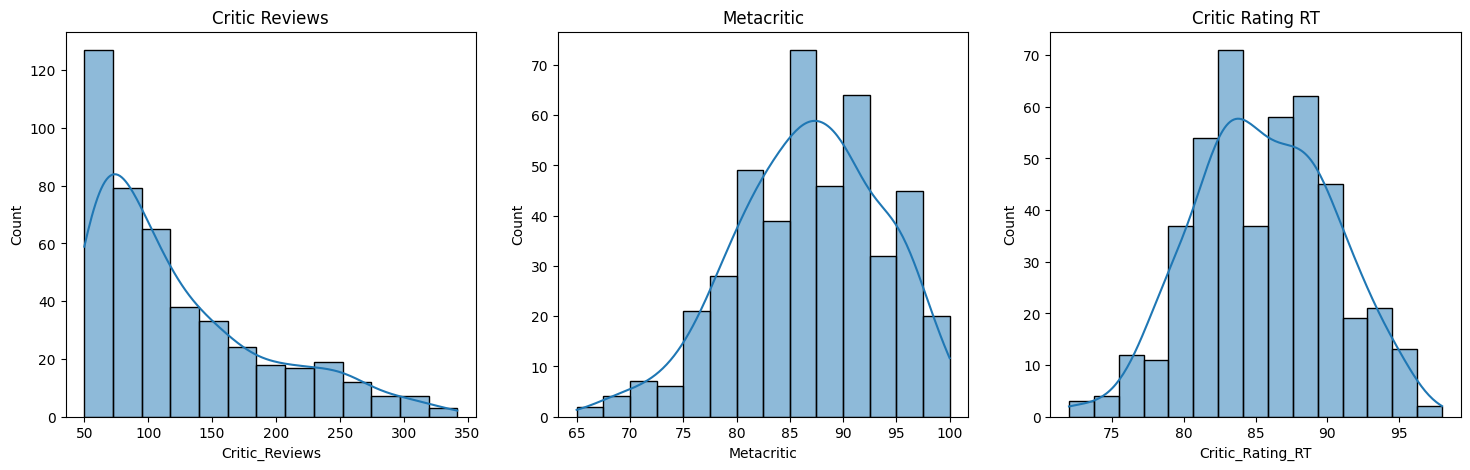

In [50]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(data_formate["Critic_Reviews"], kde=True)
plt.title("Critic Reviews")

plt.subplot(1, 3, 2)
sns.histplot(data_formate["Metacritic"], kde=True)
plt.title("Metacritic")

plt.subplot(1, 3, 3)
sns.histplot(data_formate["Critic_Rating_RT"], kde=True)
plt.title("Critic Rating RT")


plt.show()

In [53]:
data_formate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              449 non-null    object 
 1   Year               449 non-null    int64  
 2   Genre              449 non-null    object 
 3   Director           449 non-null    object 
 4   Production         329 non-null    object 
 5   Flickmetrix_Score  449 non-null    float64
 6   IMDb_100           449 non-null    float64
 7   IMDb_Votes         449 non-null    int64  
 8   Metacritic         436 non-null    float64
 9   Critic_Rating_RT   449 non-null    float64
 10  Critic_Reviews     449 non-null    int64  
 11  Audience_Rating    401 non-null    float64
 12  Audience_Reviews   442 non-null    float64
 13  Letterboxd         449 non-null    int64  
 14  Letterboxd_Votes   449 non-null    float64
 15  Google_Score       446 non-null    float64
 16  Custom_Score       449 non

In [ ]:
data_formate[""]

#### What are the important metrics?

Quality :-> IMDb_10, Metacritic, Critic_Rating_RT, Audience_Rating, Letterboxd, Google_Score, Custom_Score

Popularity :-> IMDb_Votes, Letterboxd_Votes, Audience_Reviews

Movie Information :-> Year, Genre, Director, Cast

Availability :-> Streaming_On

### Q1. Do critics and audiences agree?

Metacritic
vs
Audience_Rating

In [54]:
data_formate.corr(numeric_only=True)["Custom_Score"].sort_values(ascending=False)

Custom_Score         1.000000
Flickmetrix_Score    0.957616
IMDb_100             0.713435
Audience_Rating      0.690432
Letterboxd           0.634486
Critic_Rating_RT     0.612147
Metacritic           0.512161
Google_Score         0.329718
IMDb_Votes           0.267163
Letterboxd_Votes     0.103449
Audience_Reviews    -0.066638
Critic_Reviews      -0.166536
Year                -0.336219
Name: Custom_Score, dtype: float64

In [55]:
cols = ["Metacritic","Critic_Rating_RT","Audience_Rating","IMDb_100","Letterboxd","Google_Score"]

data_formate[cols].isnull().sum()

Metacritic          13
Critic_Rating_RT     0
Audience_Rating     48
IMDb_100             0
Letterboxd           0
Google_Score         3
dtype: int64

In [59]:
missing_audience = data_formate[
    data_formate["Audience_Rating"].isna()
]

missing_audience["Year"].value_counts().sort_index()

Year
1937     1
2020     2
2021     5
2022    14
2023    17
2024     7
2025     2
Name: count, dtype: int64

### Q2. Does popularity mean quality?

IMDb_Votes, Letterboxd_Votes

vs

Custom_Score

### Q3. Are modern movies better than older movies?
Year
vs
Custom_Score

### Q4. Which genre creates the best movies?
Genre
vs
Custom_Score

### Q5. Which genre is most popular?
Genre
vs
IMDb_Votes

### Q6. Which directors consistently deliver quality?
Director
vs
Custom_Score


### Q7. Which streaming platform has the highest-quality content?
Streaming_On
vs
Custom_Score

### Q8. What drives audience engagement?
Audience_Reviews

Does engagement increase with:
- IMDb Score?
- Metacritic?
- Letterboxd?
- Year?

### Q9. Which movies are overrated or underrated?

Large positive gap: 
- Audience loves
- Critics dislike

Large negative gap:
- Critics love
- Audience dislikes
